# importing libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

### importing dataset

In [3]:
df = pd.read_csv('financial_loan.csv')

In [3]:
df.head(5)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11/02/2021,13/09/2021,13/04/2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01/01/2021,14/12/2021,15/01/2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05/01/2021,12/12/2021,09/01/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25/02/2021,12/12/2021,12/03/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01/01/2021,14/12/2021,15/01/2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.tail(5)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,11/07/2021,16/05/2021,16/05/2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,11/10/2021,16/04/2021,16/05/2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,11/09/2021,16/05/2021,16/05/2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,11/10/2021,16/05/2021,16/05/2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,11/07/2021,16/05/2021,16/05/2021,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### metadata of data

In [5]:
print("The metadata of the dataset",df.shape)

The metadata of the dataset (38576, 24)


In [6]:
print("The metadata of the dataset",df.shape[0])

The metadata of the dataset 38576


In [7]:
print("The metadata of the dataset",df.shape[1])

The metadata of the dataset 24


In [8]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

In [9]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership  issue_date  \
0                                Ryder     C           RENT  11/02/2021   
1                       MKC Accounting     E           RENT  01/01/2021   
2                Chema

In [10]:
df.dtypes

id                         int64
address_state             object
application_type          object
emp_length                object
emp_title                 object
grade                     object
home_ownership            object
issue_date                object
last_credit_pull_date     object
last_payment_date         object
loan_status               object
next_payment_date         object
member_id                  int64
purpose                   object
sub_grade                 object
term                      object
verification_status       object
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [11]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


# Primary KPI's

In [12]:
total_loan_applications=df['id'].count()
print("Total loan application:",total_loan_applications)

Total loan application: 38576


## Month to date (MTD) - Total loan application

In [13]:
# convert issue_date to datetime with day-first formt
df['issue_date']=pd.to_datetime(df['issue_date'],dayfirst=True)

#find latest issue date
latest_issue_date=df['issue_date'].max()

#extract year and month
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month

#filter data for that month
mtd_data=df[(df['issue_date'].dt.year==latest_year)&
            (df['issue_date'].dt.month==latest_month)]

#count application
mtd_loan_applications=mtd_data['id'].count()

#print result
print(f"Month-to-date loan application (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

Month-to-date loan application (for December 2021): 4314


## total funded amount

In [14]:
total_funded_amount=df['loan_amount'].sum()
total_funded_amount_millions=total_funded_amount/1_000_000
print("Total funded amount in millions: ₹{:.2f}M".format(total_funded_amount_millions))

Total funded amount in millions: ₹435.76M


## MTD total funded amount


In [15]:
# convert issue_date to datetime with day-first formt
df['issue_date']=pd.to_datetime(df['issue_date'],dayfirst=True)

#find latest issue date
latest_issue_date=df['issue_date'].max()

#extract year and month
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month

#filter data for that month
mtd_data=df[(df['issue_date'].dt.year==latest_year)&
            (df['issue_date'].dt.month==latest_month)]

#calculate MTD total funded amount
mtd_total_funded_amt=mtd_data['loan_amount'].sum()
mtd_total_funded_amt_millions=mtd_total_funded_amt/1_000_000

#print result
print("MTD total funded amount({} {}): ₹{:.2f}M".format(
    latest_issue_date.strftime('%B'), latest_issue_date.year, mtd_total_funded_amt_millions))

MTD total funded amount(December 2021): ₹53.98M


## total amount recieved

In [16]:
total_received=df['total_payment'].sum()
total_received_millions=total_received/1_000_000
print("Total amount received in millions: ₹{:.2f}M".format(total_received_millions))

Total amount received in millions: ₹473.07M


## MTD total amount recieved

In [17]:
# convert issue_date to datetime with day-first formt
df['issue_date']=pd.to_datetime(df['issue_date'],dayfirst=True)

#find latest issue date
latest_issue_date=df['issue_date'].max()

#extract year and month
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month

#filter data for that month
mtd_data=df[(df['issue_date'].dt.year==latest_year)&
            (df['issue_date'].dt.month==latest_month)]

#calculate MTD total funded amount
mtd_total_received=mtd_data['total_payment'].sum()
mtd_total_received_millions=mtd_total_received/1_000_000

#print result
print("MTD total amount received({} {}): ₹{:.2f}M".format(
    latest_issue_date.strftime('%B'), latest_issue_date.year, mtd_total_received_millions))

MTD total amount received(December 2021): ₹58.07M


## average interest rate

In [18]:
average_interest_rate=df['int_rate'].mean()*100
print("Average interest rate: {:.2f}%".format(average_interest_rate))

Average interest rate: 12.05%


## average DTI

In [19]:
average_dti=df['dti'].mean()*100
print("Average DTI: {:.2f}%".format(average_dti))

Average DTI: 13.33%


# Secondary KPI's

In [20]:
# Good loan condition(fully paid/current)
good_loan=df[df['loan_status'].isin(["Fully Paid", "Current"])]
#total loan application
total_loan_application=df['id'].count()
#good loan calculation
good_loan_applications=good_loan['id'].count()
good_loan_funded_amount=good_loan['loan_amount'].sum()
good_loan_received=good_loan['total_payment'].sum()
#convert to millions
good_loan_funded_amount_millions=good_loan_funded_amount/1_000_000
good_loan_received_millions=good_loan_received/1_000_000
#percentage of good loan
good_loan_percentage=(good_loan_applications/total_loan_applications)*100
#print result
print("Good loan application:", good_loan_applications)
print("Good loan funded amount (in millions): ₹{:.2f}M".format(good_loan_funded_amount_millions))
print("Good loan total received (in millions): ₹{:.2f}M".format(good_loan_received_millions))
print("Percentage of good loan application: {:.2f}%".format(good_loan_percentage))

Good loan application: 33243
Good loan funded amount (in millions): ₹370.22M
Good loan total received (in millions): ₹435.79M
Percentage of good loan application: 86.18%


In [21]:
# Bad loan condition(fully paid/current)
bad_loan=df[df['loan_status'].isin(["Charged Off"])]
#total loan application
total_loan_application=df['id'].count()
#bad loan calculation
bad_loan_applications=bad_loan['id'].count()
bad_loan_funded_amount=bad_loan['loan_amount'].sum()
bad_loan_received=bad_loan['total_payment'].sum()
#convert to millions
bad_loan_funded_amount_millions=bad_loan_funded_amount/1_000_000
bad_loan_received_millions=bad_loan_received/1_000_000
#percentage of bad loan
bad_loan_percentage=(bad_loan_applications/total_loan_applications)*100
#print result
print("Bad loan application:", bad_loan_applications)
print("Bad loan funded amount (in millions): ₹{:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad loan total received (in millions): ₹{:.2f}M".format(bad_loan_received_millions))
print("Percentage of bad loan application: {:.2f}%".format(bad_loan_percentage))

Bad loan application: 5333
Bad loan funded amount (in millions): ₹65.53M
Bad loan total received (in millions): ₹37.28M
Percentage of bad loan application: 13.82%


## total funded amount by month

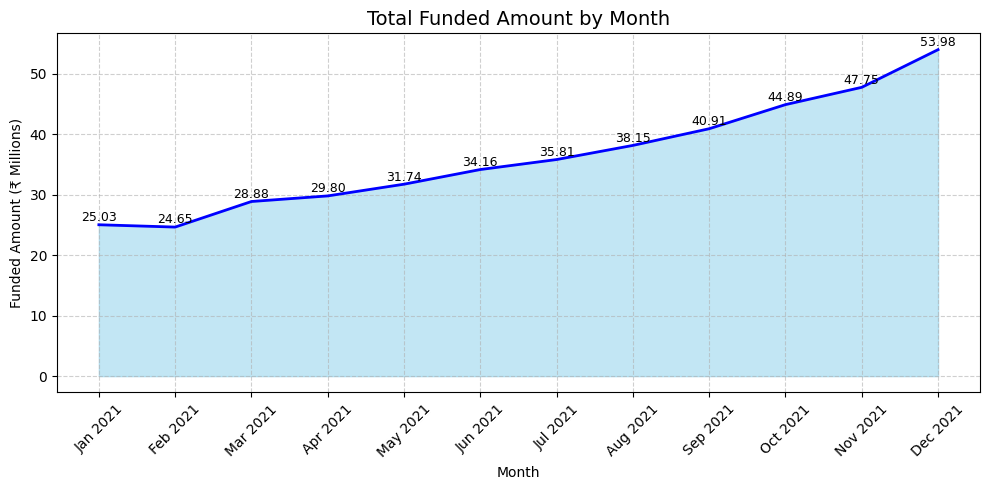

In [22]:

# Ensure 'issue_date' is in datetime format
df['issue_date'] = pd.to_datetime(df['issue_date'])

# Create 'Month Year' label
df['month_name'] = df['issue_date'].dt.strftime('%b %Y')

# Sort the DataFrame by issue_date
df = df.sort_values('issue_date')

# Group by month and get total funded amount
monthly_funded = df.groupby('month_name', sort=False)['loan_amount'].sum().reset_index()

# Convert to millions
monthly_funded['loan_amount_millions'] = monthly_funded['loan_amount'] / 1000000

# Plotting
plt.figure(figsize=(10, 5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='blue', linewidth=2)

# Add data labels
for i, row in monthly_funded.iterrows():
    plt.text(row['month_name'], row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}", 
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

# Chart formatting
plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (₹ Millions)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Total Received Amount by Month

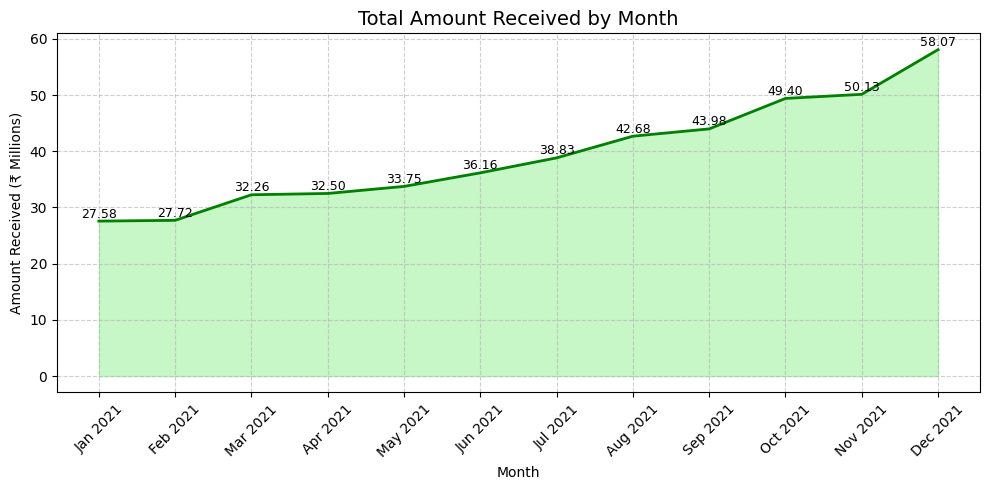

In [23]:
# Make sure 'issue_date' is datetime
df['issue_date'] = pd.to_datetime(df['issue_date'])

# Create 'Month Year' column for grouping
df['month_name'] = df['issue_date'].dt.strftime('%b %Y')

# Sort by date to keep month order intact
df = df.sort_values('issue_date')

# Group by month and calculate total received
monthly_received = df.groupby('month_name', sort=False)['total_payment'].sum().reset_index()

# Convert to ₹ millions
monthly_received['total_payment_millions'] = monthly_received['total_payment'] / 1_000_000

# Plotting the area chart
plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name'], monthly_received['total_payment_millions'], color='lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'], monthly_received['total_payment_millions'], color='green', linewidth=2)

# Add data labels
for i, row in monthly_received.iterrows():
    plt.text(row['month_name'], row['total_payment_millions'] + 0.1, f"{row['total_payment_millions']:.2f}", 
             ha='center', va='bottom', fontsize=9, color='black')

# Chart formatting
plt.title('Total Amount Received by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Amount Received (₹ Millions)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Total Applications by Month

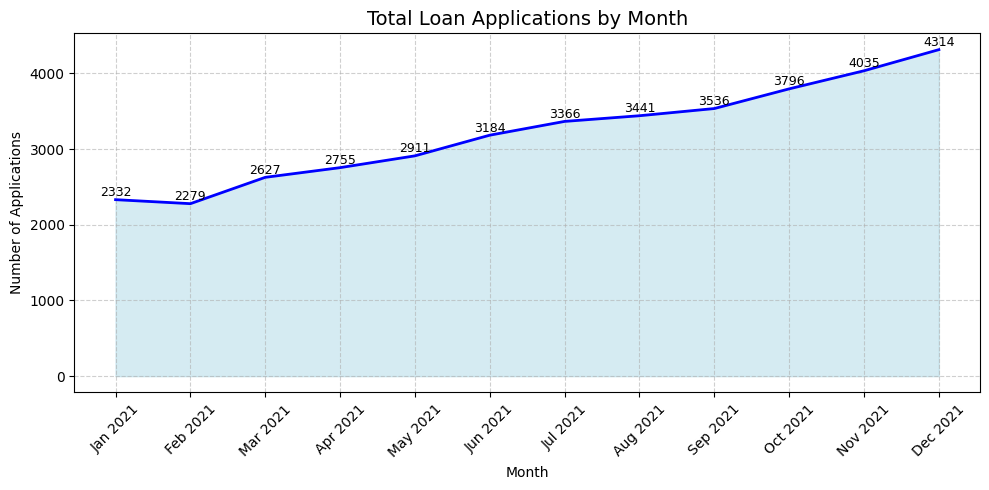

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure 'issue_date' is datetime
df['issue_date'] = pd.to_datetime(df['issue_date'])

# Create 'Month Year' column for grouping
df['month_name'] = df['issue_date'].dt.strftime('%b %Y')

# Sort by issue date to maintain month order
df = df.sort_values('issue_date')

# Group by month and count loan applications
monthly_applications = df.groupby('month_name', sort=False)['id'].count().reset_index()
monthly_applications.rename(columns={'id': 'total_applications'}, inplace=True)

# Plotting the area chart
plt.figure(figsize=(10, 5))
plt.fill_between(monthly_applications['month_name'], monthly_applications['total_applications'], color='lightblue', alpha=0.5)
plt.plot(monthly_applications['month_name'], monthly_applications['total_applications'], color='blue', linewidth=2)

# Add data labels
for i, row in monthly_applications.iterrows():
    plt.text(row['month_name'], row['total_applications'] + 5, f"{row['total_applications']}", 
             ha='center', va='bottom', fontsize=9, color='black')

# Chart formatting
plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Total Funded Amount by State

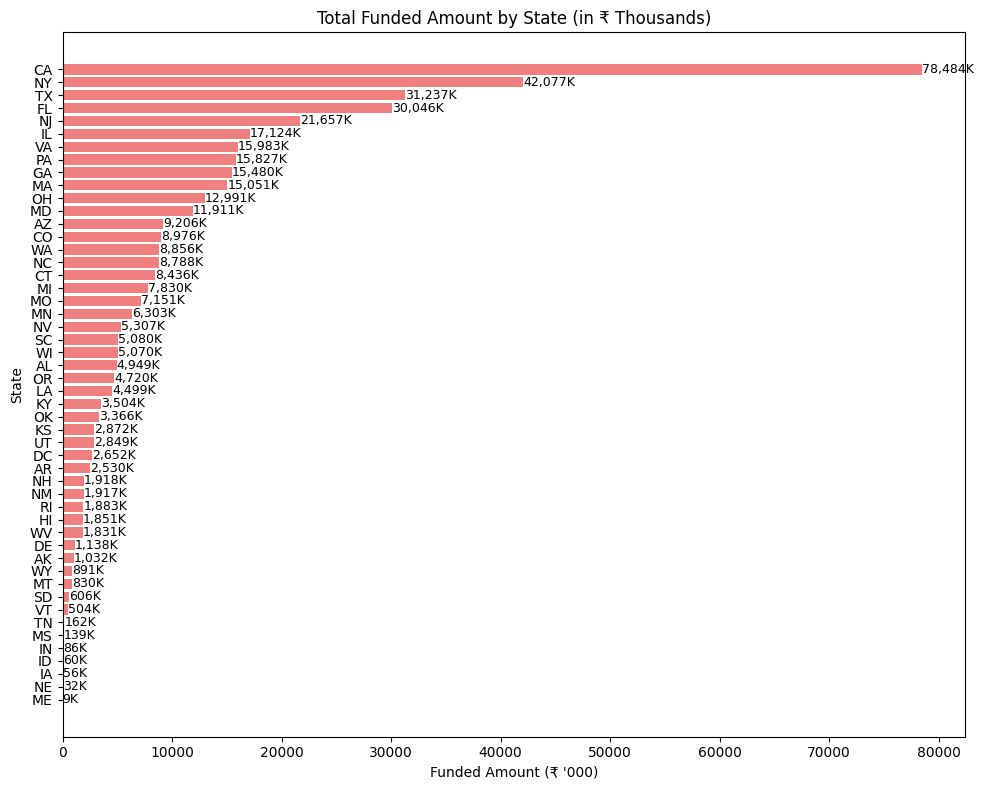

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by state and sum loan amounts (in thousands)
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000  # convert to ₹ '000

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

# Add data labels with 'K'
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel('Funded Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Total Received Amount by State

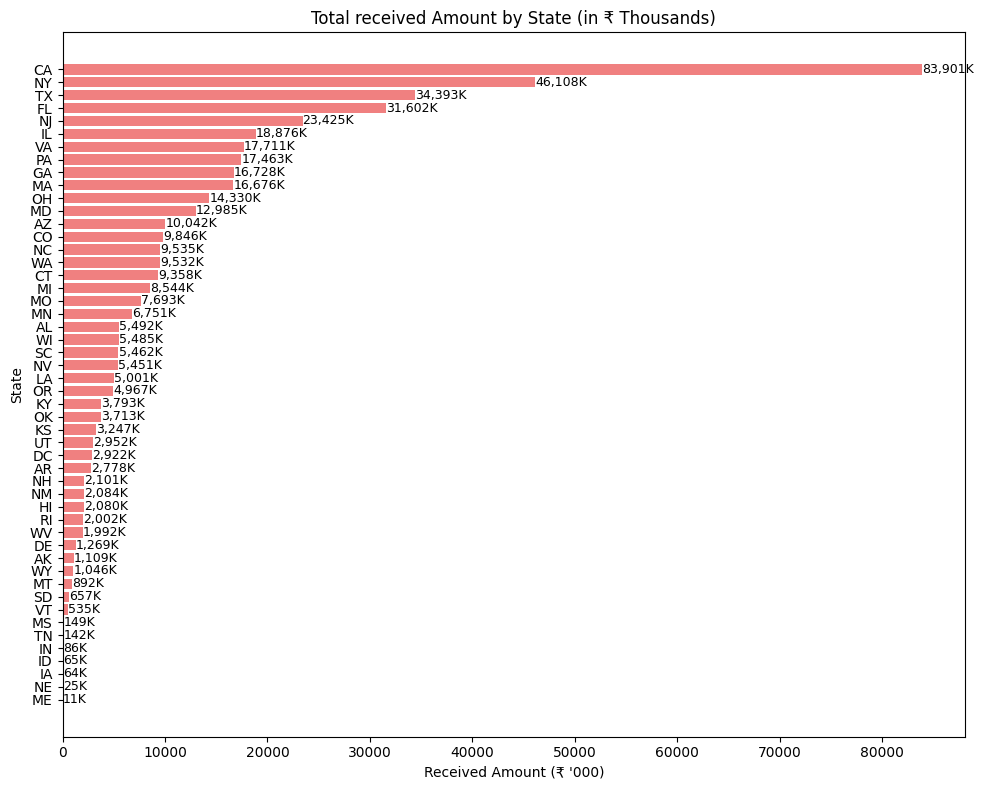

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by state and sum loan amounts (in thousands)
state_funding = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000  # convert to ₹ '000

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

# Add data labels with 'K'
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total received Amount by State (in ₹ Thousands)')
plt.xlabel('Received Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Total Applications by State

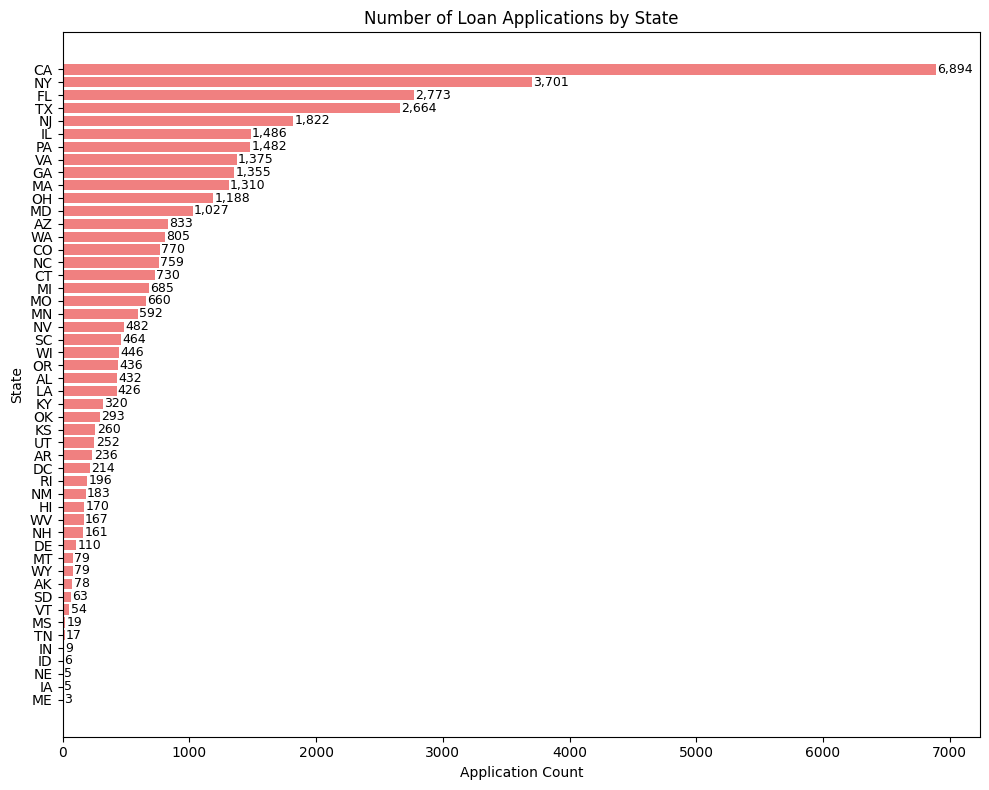

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Number of applications per state
state_counts = df.groupby('address_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(state_counts.index, state_counts.values, color='lightcoral')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,}', va='center', fontsize=9)

plt.title('Number of Loan Applications by State')
plt.xlabel('Application Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()


## Total Funded Amount by Term

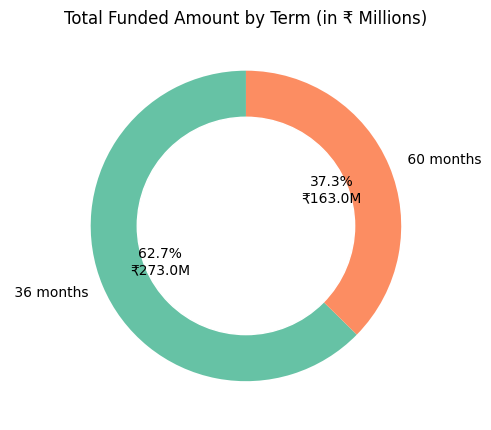

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Group total funded amount by term
term_funding = df.groupby('term')['loan_amount'].sum()

# Convert to ₹ Millions
term_funding_millions = term_funding / 1_000_000

# Function to display both percent and amount
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    amount = allvals[absolute == allvals].values[0] if absolute in allvals.values else absolute
    return f"{pct:.1f}%\n₹{amount:.1f}M"

# Plotting the donut chart
plt.figure(figsize=(5, 5))
colors = ['#66c2a5', '#fc8d62']  # Customize if needed

wedges, texts, autotexts = plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda pct: autopct_format(pct, term_funding_millions),
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.4}
)

# Draw center circle
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Funded Amount by Term (in ₹ Millions)")
plt.tight_layout()
plt.show()

## Total Received Amount by Term

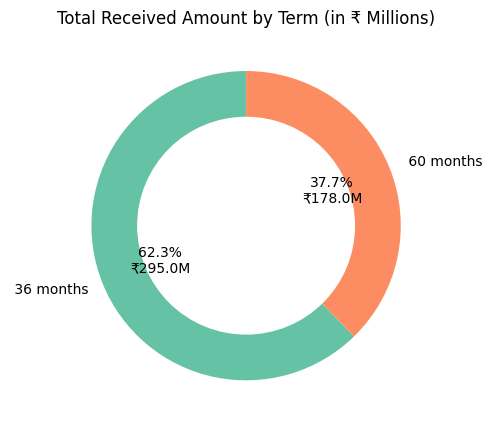

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Group total received amount by term
term_funding = df.groupby('term')['total_payment'].sum()

# Convert to ₹ Millions
term_funding_millions = term_funding / 1_000_000

# Function to display both percent and amount
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    amount = allvals[absolute == allvals].values[0] if absolute in allvals.values else absolute
    return f"{pct:.1f}%\n₹{amount:.1f}M"

# Plotting the donut chart
plt.figure(figsize=(5, 5))
colors = ['#66c2a5', '#fc8d62']  # Customize if needed

wedges, texts, autotexts = plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda pct: autopct_format(pct, term_funding_millions),
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.4}
)

# Draw center circle
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Received Amount by Term (in ₹ Millions)")
plt.tight_layout()
plt.show()

## Total Application by Term

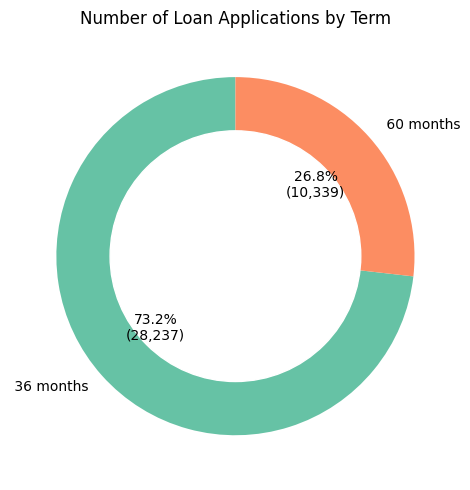

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Count of applications by term
term_counts = df.groupby('term')['id'].count()

# Function to show percent and count
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

# Plot donut chart
plt.figure(figsize=(5, 5))
colors = ['#66c2a5', '#fc8d62']  # 36-month, 60-month etc.

wedges, texts, autotexts = plt.pie(
    term_counts,
    labels=term_counts.index,
    autopct=lambda pct: autopct_format(pct, term_counts),
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.4}
)

# Donut hole
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Number of Loan Applications by Term")
plt.tight_layout()
plt.show()


## Total Funded Amount by Employee Length

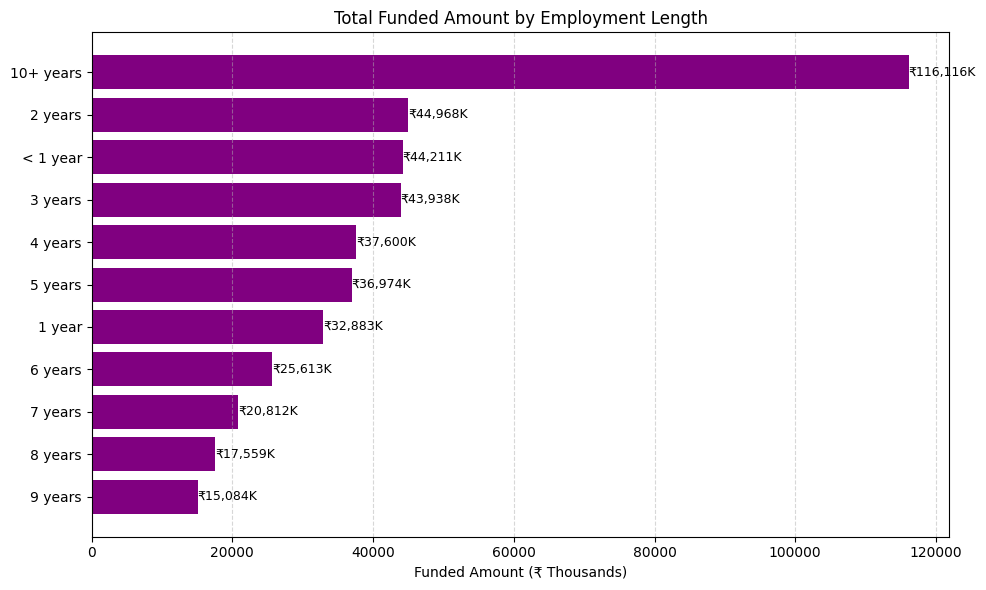

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Group total funded amount by emp_length
emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values()

# Convert to ₹ Thousands
emp_funding_thousands = emp_funding / 1_000

# Plotting horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"₹{width:,.0f}K", va='center', fontsize=9)

# Chart formatting
plt.xlabel("Funded Amount (₹ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Total Received Amount by Employee Length

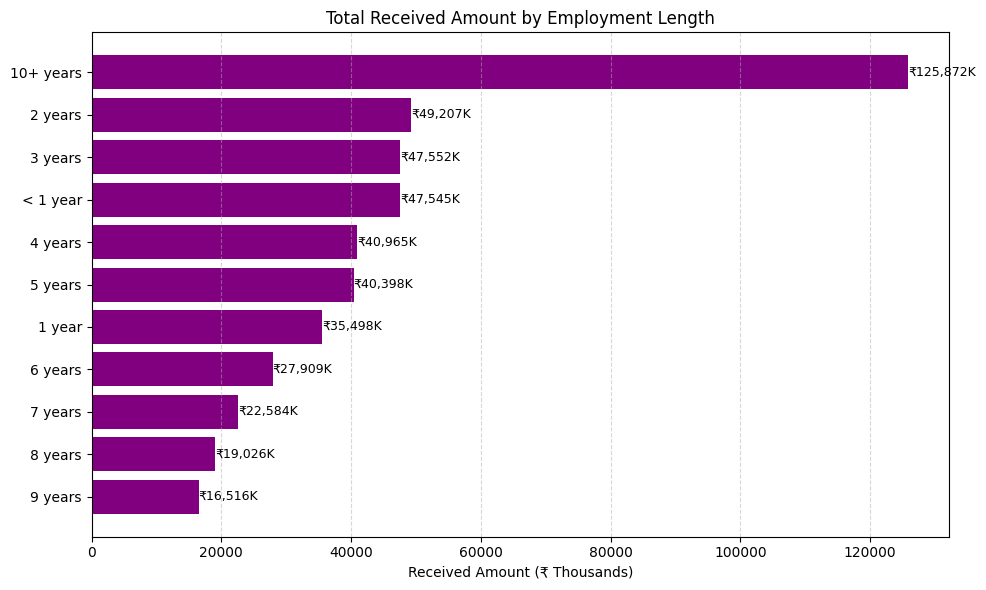

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Group total received amount by emp_length
emp_funding = df.groupby('emp_length')['total_payment'].sum().sort_values()

# Convert to ₹ Thousands
emp_funding_thousands = emp_funding / 1_000

# Plotting horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"₹{width:,.0f}K", va='center', fontsize=9)

# Chart formatting
plt.xlabel("Received Amount (₹ Thousands)")
plt.title("Total Received Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Total Application by Employee Length

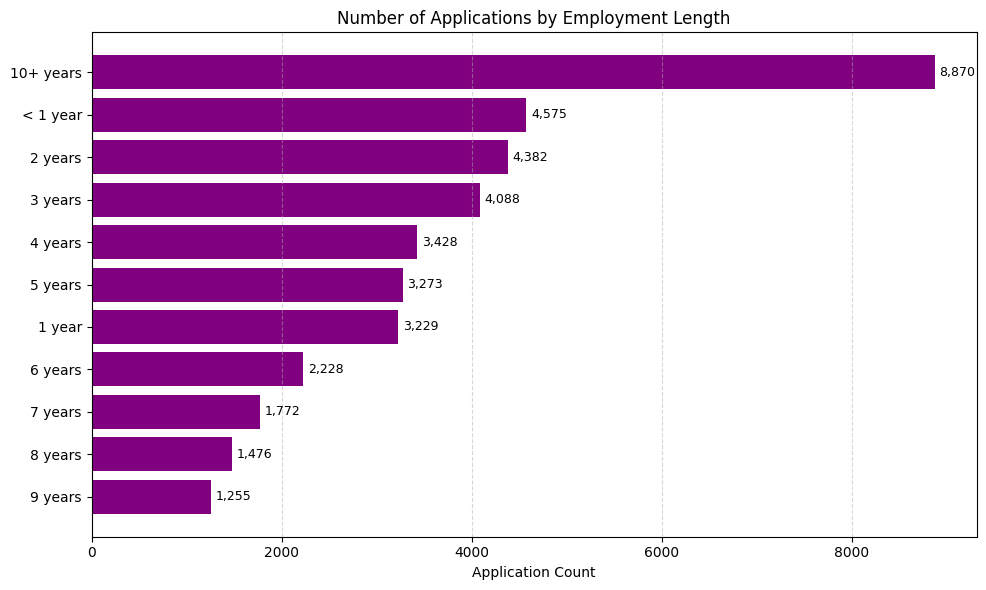

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Count applications by employment length
emp_counts = df.groupby('emp_length')['id'].count().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_counts.index, emp_counts, color='purple')

# Add count labels
for bar in bars:
    count = bar.get_width()
    plt.text(count + 50, bar.get_y() + bar.get_height() / 2,
             f"{count:,}", va='center', fontsize=9)

# Chart formatting
plt.xlabel("Application Count")
plt.title("Number of Applications by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Total Funded Amount by Purpose

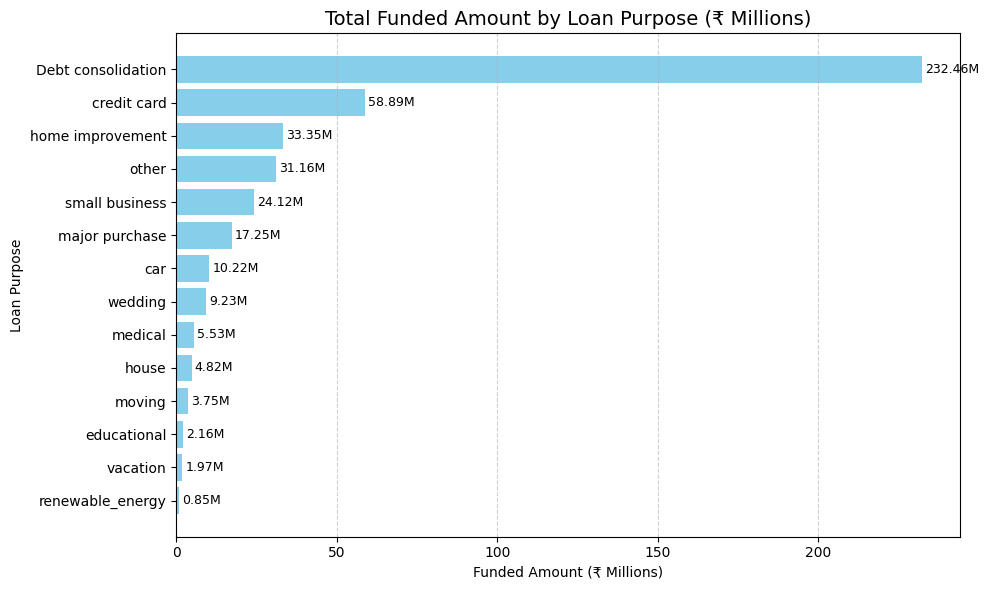

In [44]:
# Group by purpose and calculate total loan amount
purpose_funding = df.groupby('purpose')['loan_amount'].sum().reset_index()
purpose_funding = purpose_funding.sort_values(by='loan_amount', ascending=True)  # Ascending for horizontal bar chart

# Convert to ₹ millions
purpose_funding['loan_amount_millions'] = purpose_funding['loan_amount'] / 1_000_000

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding['purpose'], purpose_funding['loan_amount_millions'], color='skyblue')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}M', va='center', fontsize=9)

# Formatting
plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Funded Amount (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Total Received Amount by Purpose

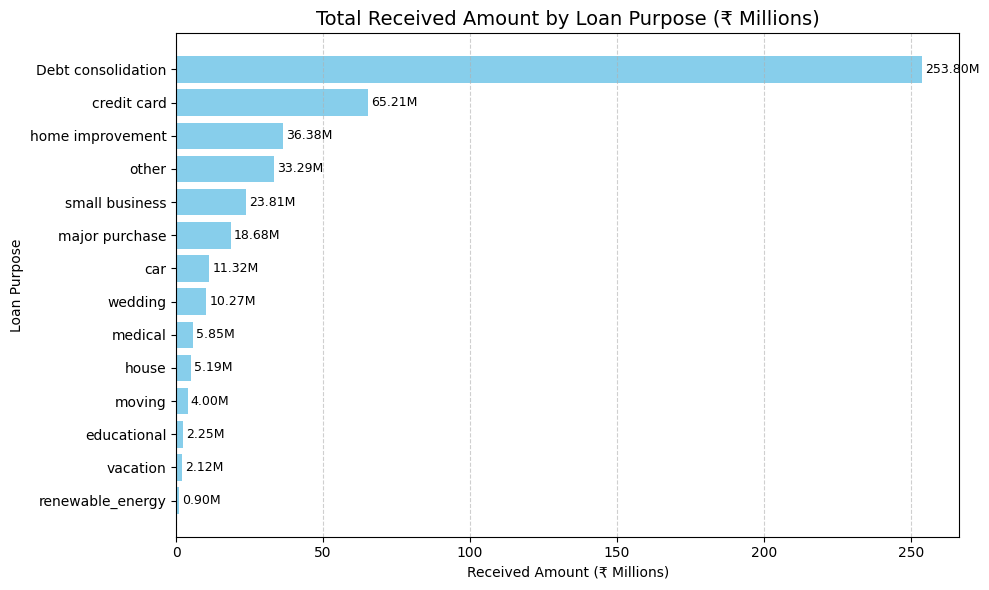

In [45]:
# Group by purpose and calculate total received amount
purpose_funding = df.groupby('purpose')['total_payment'].sum().reset_index()
purpose_funding = purpose_funding.sort_values(by='total_payment', ascending=True)  # Ascending for horizontal bar chart

# Convert to ₹ millions
purpose_funding['loan_amount_millions'] = purpose_funding['total_payment'] / 1_000_000

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding['purpose'], purpose_funding['loan_amount_millions'], color='skyblue')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}M', va='center', fontsize=9)

# Formatting
plt.title('Total Received Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Received Amount (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Total Application by Purpose

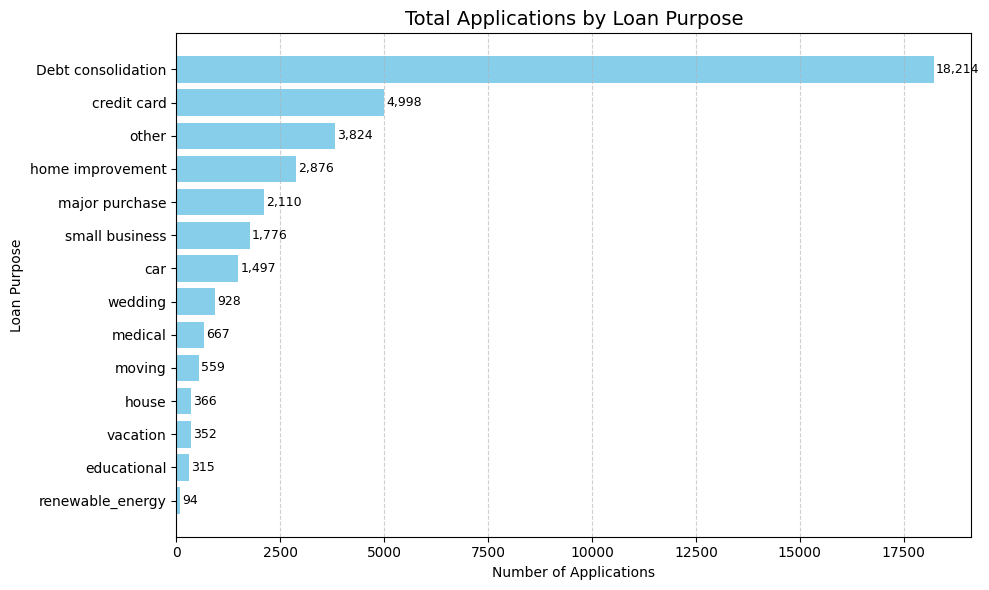

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by purpose and calculate total application count
purpose_funding = df.groupby('purpose')['id'].count().reset_index()
purpose_funding = purpose_funding.sort_values(by='id', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding['purpose'], purpose_funding['id'], color='skyblue')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2, 
             f'{width:,}', va='center', fontsize=9)

# Formatting
plt.title('Total Applications by Loan Purpose', fontsize=14)
plt.xlabel('Number of Applications')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Total Funded Amount by Home Ownership

In [6]:
import pandas as pd
import plotly.express as px

# Group by home_ownership and sum loan amount
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()

# Convert to ₹ Millions
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000

# Create Tree Map
fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()


In [51]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------- ----------------- 5.5/9.9 MB 28.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 26.7 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 18.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1
Note: you may need to restart the kernel to use updated packages.
